In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
import missingno as msno
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)

%matplotlib inline

/opt/anaconda3/envs/machinelearning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
SENTINEL_OUTGOINGS = -1
FEATURES = ['Income', 'Outgoings', 'NetDisposable']
OUTPUT_DIR = 'Output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# load the dataset

df = pd.read_csv('./Data/previousApplicants.csv')

In [4]:
# plot missing data 

def plot_missing_data(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Missing data matrix - shows location of nulls
    msno.matrix(df, ax=axes[0], sparkline=False, fontsize=10)
    axes[0].set_title("Missing Data Matrix (Raw Data)", fontsize=13, fontweight="bold")

    # Bar chart of completeness per column
    msno.bar(df, ax=axes[1], fontsize=10, color="steelblue")
    axes[1].set_title("Column Completeness (Raw Data)", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"missing_data_overview.png"), dpi=150)
    plt.show()


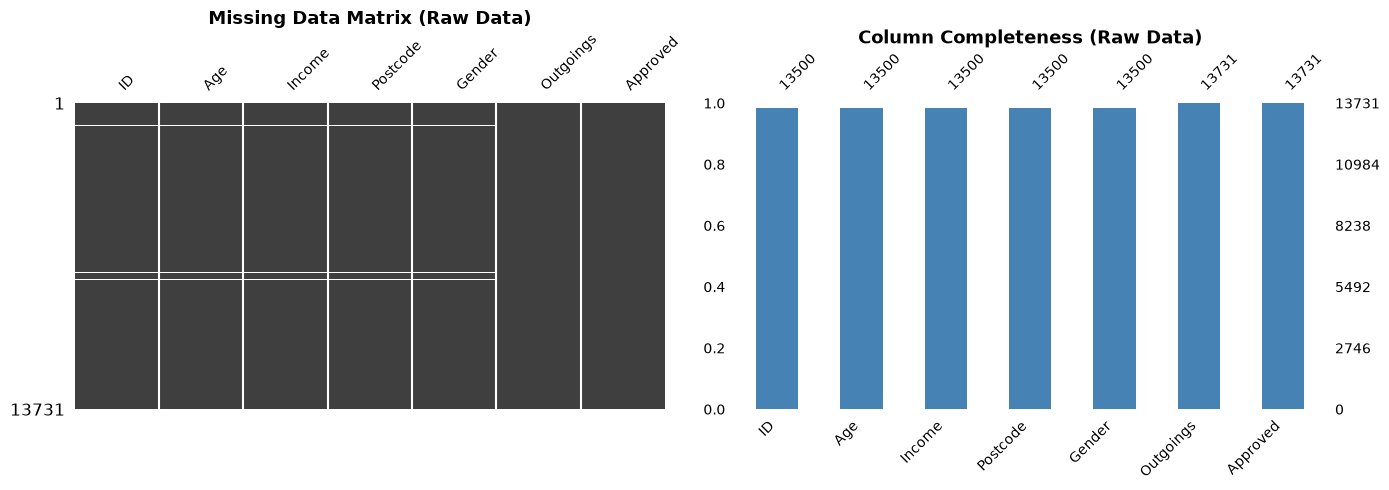

In [5]:
plot_missing_data(df)

In [6]:
# check for missing values in the dataset
df.isnull().sum()

ID           231
Age          231
Income       231
Postcode     231
Gender       231
Outgoings      0
Approved       0
dtype: int64

In [7]:
# check for unique values in the dataset
df.nunique()

ID           12500
Age             79
Income       11977
Postcode     12454
Gender           3
Outgoings     9768
Approved         2
dtype: int64

In [8]:
# check for gender type count in the dataset
df['Gender'].value_counts()

Gender
a    6785
b    6714
c       1
Name: count, dtype: int64

In [9]:
# Clean the dataset by removing rows with missing IDs, replacing 'nil' in Income with NaN, and replacing SENTINEL_OUTGOINGS in Outgoings with NaN. Then, group by ID and aggregate the first non-null values for each column.
def clean_data(df):
    df = df[df['ID'].notna()].copy()

    df['Income'] = df['Income'].replace('nil', pd.NA)
    df['Outgoings'] = df['Outgoings'].astype(str).replace(SENTINEL_OUTGOINGS, pd.NA)

    cleaned_df = (df.sort_values(by='ID').groupby('ID', as_index=False).agg({
        'Age': 'first', 
        'Postcode': 'first', 
        'Gender': 'first', 
        'Approved': 'first', 
        'Income': lambda s: s.dropna().iloc[0] if s.notna().any() else pd.NA,
        'Outgoings': lambda s: s.dropna().iloc[0] if s.notna().any() else pd.NA,
    }))

    cleaned_df['ID'] = cleaned_df['ID'].astype(int)
    cleaned_df['Age'] = cleaned_df['Age'].astype(int)
    cleaned_df['Income'] = cleaned_df['Income'].astype(float).astype(int)
    cleaned_df['Outgoings'] = cleaned_df['Outgoings'].astype(float).astype(int)
    cleaned_df['Approved'] = cleaned_df['Approved'].astype(bool)

    return cleaned_df

df = clean_data(df)

In [10]:
# Feature engineering: Create a new column 'NetDisposable' by subtracting 'Outgoings' from 'Income'.
def build_features(df):
    df = df.copy()
    df['NetDisposable'] = df['Income'] - df['Outgoings']

    return df

In [11]:
df = build_features(df)

df.describe()

corr_matrix = df.corr(numeric_only=True)
corr_matrix["Income"].sort_values(ascending=False)

Income           1.000000
Approved         0.349934
ID               0.010510
NetDisposable    0.008994
Age             -0.001043
Outgoings       -0.008994
Name: Income, dtype: float64

/opt/anaconda3/envs/machinelearning/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:68: RuntimeWarning: overflow encountered in scalar subtract
  rdelta_ext = (rmax_ - rmin_) * range_padding / 2


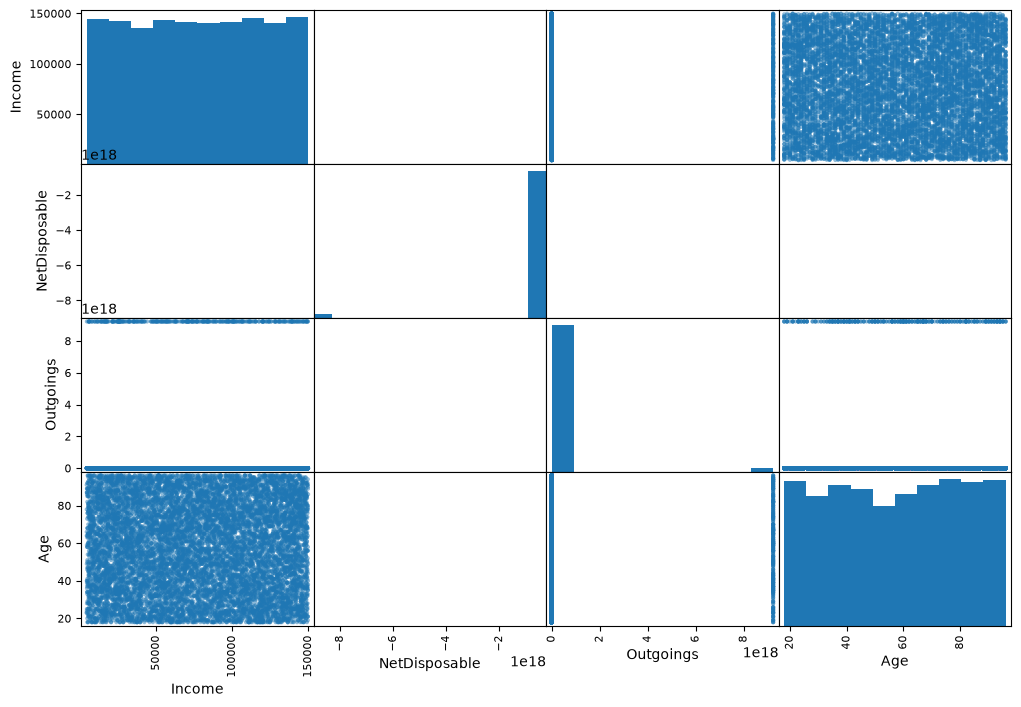

In [16]:
from pandas.plotting import scatter_matrix

attributes = ["Income", "NetDisposable", "Outgoings", "Age"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

In [12]:
def make_model():
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        regularization_lambda=1,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    )
    return model

In [13]:
# Train model

def train_model(df):
    X = df[FEATURES]
    y = df['Approved'].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    model = make_model()
    model.fit(X_train, y_train)

    cv = cross_val_score(make_model(), X_train, y_train, cv=5, scoring='roc_auc')

    print(f"5-fold CV ROC-AUC: {cv.mean():.3f} (+/-{cv.std():.3f})")

    return {'model': model, 'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}


In [14]:
def evaluate_model(bundle):
    model, X_test, y_test = bundle['model'], bundle['X_test'], bundle['y_test']
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
 
    row = {'Accuracy': accuracy_score(y_test, pred),
           'Precision': precision_score(y_test, pred),
           'Recall': recall_score(y_test, pred),
           'F1': f1_score(y_test, pred),
           'ROC_AUC': roc_auc_score(y_test, proba)}
    print("\nXGBoost test-set metrics:")
    for k, v in row.items():
        print(f"  {k:10s}: {v:.4f}")
    print("\nClassification report:\n",
          classification_report(y_test, pred, target_names=['Rejected', 'Approved']))
    return {'pred': pred, 'proba': proba, 'metrics': row}
